## Step 1: Set Up the Environment

The first code cell below is a one-time setup step. It performs three key actions:
1.  **Clones the GitHub repository:** This downloads all our workshop files, including helper code and the sample images.
2.  **Changes the directory:** It navigates into the newly downloaded folder so we can access those files.
3.  **Installs packages:** It installs the specific libraries listed in `requirements.txt`.

▶️ **Please run this cell now.** It might take a minute to complete. You'll see a "✅ Setup complete!" message when it's finished.

In [6]:
# Environment Setup
import os

repo_url = "https://github.com/japheth45/Adversarial_ML25.git"
repo_dir = "Adversarial_ML25"

# Clone the repository
!git clone {repo_url}

# Check if the clone was successful by seeing if the directory exists
if os.path.isdir(repo_dir):
  print("✅ Repository cloned successfully.")
  %cd {repo_dir}
  print("Installing required packages...")
  !pip install -q -r requirements.txt # The -q flag makes the output quieter
  print("✅ Setup complete!")
else:
  print("❌ Error: Could not clone the repository.")
  print("Please check the URL and ensure the repository is public.")

[WinError 2] The system cannot find the file specified: 'ml-workshop-repo'
C:\Users\Student\PycharmProjects\imgMLforGithub


Cloning into 'ml-workshop-repo'...
fatal: User cancelled dialog.
bash: line 1: /dev/tty: No such device or address
error: failed to execute prompt script (exit code 1)
fatal: could not read Username for 'https://github.com': No such file or directory
C:\Users\Student\PycharmProjects\imgMLforGithub\venv\lib\site-packages\IPython\core\magics\osm.py:393: UserWarning: using bookmarks requires you to install the `pickleshare` library.
  bkms = self.shell.db.get('bookmarks', {})


✅ Setup complete!


ERROR: Could not open requirements file: [Errno 2] No such file or directory: 'requirements.txt'
You should consider upgrading via the 'C:\Users\Student\PycharmProjects\imgMLforGithub\venv\Scripts\python.exe -m pip install --upgrade pip' command.


## Step 2: Import Libraries

Now that our environment is ready, this cell imports all the necessary tools for our session. This includes standard libraries like `torch` and `PIL` (for image handling), as well as the custom helper functions we've written for this workshop (like `classify` and `load_image`).

▶️ **Run this cell to load everything into memory.** It should complete in just a second.

In [3]:
# Imports
from PIL import Image
from IPython.display import display
from image_helpers import classify, label_to_index, load_image, embed_crop_back, get_model
import torch, torchvision

Original Image:


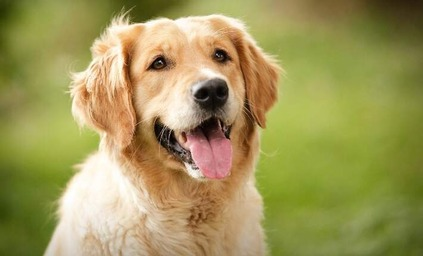


Top 5 Predictions:


[('golden retriever', 0.39344272017478943),
 ('Brittany spaniel', 0.01776575669646263),
 ('flat-coated retriever', 0.007300310768187046),
 ('tennis ball', 0.006412166636437178),
 ('clumber', 0.004792073275893927)]


Conclusion: The model is confident this is a 'golden retriever'.


In [4]:
# Cell 3: The Main Exercise - Classify the Dog

# Define the image we will be attacking
img_path = "data/dog.jpg"

# Show the original image and its top-5 predictions
print("Original Image:")
display(Image.open(img_path))

predictions = classify(img_path)
print("\nTop 5 Predictions:")
display(predictions)

original_label = predictions[0][0]
print(f"\nConclusion: The model is confident this is a '{original_label}'.")

In [ ]:
# --- Time for the attack! ---

def generate_adversarial_example(image_path, target_label_name, eps=8/255, alpha=2/255, iters=100, stop_threshold=0.90):
    """
    Generates a targeted adversarial example using PGD with an early stopping condition.
    """
    model, dev = get_model()
    x, _ = load_image(image_path)
    target_idx = label_to_index(target_label_name)
    target_y = torch.tensor([target_idx], device=dev)

    # Define the mean and std used for normalization
    mean = torch.tensor([0.485, 0.456, 0.406], device=dev).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225], device=dev).view(3, 1, 1)

    # The perturbation starts as zero
    delta = torch.zeros_like(x, requires_grad=True)

    for i in range(iters):
        logits = model(x + delta)
        loss = torch.nn.functional.cross_entropy(logits, target_y)
        loss.backward()

        # The perturbation `delta` is updated. Its values are in the normalized space.
        # We clamp the *change* to stay within our pixel-space budget `eps`.
        # Note: A more rigorous implementation would scale eps by std, but this is a reasonable simplification.
        delta.data = (delta - alpha * delta.grad.sign()).clamp(-eps, eps)
        delta.grad.zero_()

        with torch.no_grad():
            probs = torch.softmax(model(x + delta), dim=1)
            target_prob = probs[0, target_idx].item()
            print(f"Iteration {i+1}: Loss = {loss.item():.4f}, Target Confidence = {target_prob:.2%}")
            if target_prob > stop_threshold:
                print(f"✅ Stopping early at iteration {i+1} (confidence {target_prob:.2%})")
                break

    print("\nAttack finished!")

    # --- THIS IS THE CRITICAL FIX ---
    # Create the final adversarial image by adding the perturbation to the ORIGINAL normalized image
    adv_x = x + delta

    # Un-normalize the adversarial image to convert it back to the [0, 1] pixel space
    adv_unnormalized = adv_x * std + mean

    # Clamp the final image to the valid [0, 1] range and return
    return torch.clamp(adv_unnormalized, 0, 1)


# --- Let's run it! ---
target = "chain saw"
print(f"Running targeted attack towards: '{target}'")

# Generate the adversarial tensor
adv_tensor = generate_adversarial_example(img_path, target, stop_threshold=0.98) # Experiment with this value!

# Convert tensor to PIL Image to view and save
adv_pil = torchvision.transforms.ToPILImage()(adv_tensor.squeeze(0))
adv_pil.save("data/dog_adv_patch.png")
print("\nAdversarial patch saved!")
display(adv_pil)

In [ ]:
# Let's embed the small adversarial patch back into the full-size image
full_adv_path = "data/dog_adv_full.jpg"
embed_crop_back(img_path, adv_pil, save_path=full_adv_path)

# Now, let's compare the classifications
print("--- Original Image Predictions ---")
display(classify(img_path))

print("\n--- Full-Size Adversarial Image Predictions ---")
display(classify(full_adv_path))

print("\n--- Side-by-Side Comparison ---")
display(Image.open(img_path))
display(Image.open(full_adv_path))

🚀 Optional: Try Your Own Image!
Now it's your turn to be the adversary. Find an image on the web, paste the URL below, and see what the model thinks it is. Right-
click on an image online and select "Copy Image Address" or a similar option to get the URL.

In [5]:
import os
from PIL import Image

image_url = "https://images.stockcake.com/public/9/6/5/965857ff-5ab5-427f-859c-4487bffaf078_medium/shiny-truck-display-stockcake.jpg"

if image_url:
  try:
    # Get the extension from the URL and create a local filename
    _ , ext = os.path.splitext(image_url)
    local_filename = f"my_image{ext}"

    # Download the image from the URL and save it
    !wget -q -O {local_filename} {image_url}

    print("Image successfully downloaded!")
    display(Image.open(local_filename))

    print("\nTop 5 Predictions:")
    display(classify(local_filename))

  except Exception as e:
    print(f"Error: Could not download or process the image. Please try a different URL. \n{e}")
else:
  print("Please paste a URL into the field above and press the play button.")

Image successfully downloaded!
Error: Could not download or process the image. Please try a different URL. 
[Errno 2] No such file or directory: 'my_image.jpg'


'wget' is not recognized as an internal or external command,
operable program or batch file.


In [ ]:
# Define the file path for the new adversarial image
root, extension = os.path.splitext(local_filename)
adv_img = f"{root}_adv_full{extension}"

# What do you want your target classification to be?
new_target = "tennis ball"

print(f"Running targeted attack on your image, aiming for: '{new_target}'")

# Generate the adversarial tensor using the function we defined earlier
adv_tensor = generate_adversarial_example(
    local_filename,
    new_target,
    stop_threshold=0.90
)

# Convert tensor to PIL Image to view
adv_pil = torchvision.transforms.ToPILImage()(adv_tensor.squeeze(0))
display(adv_pil)

#Determine the format for the save function
if extension.lower() in ['.png']:
    file_format = "PNG"
else:
    file_format = "JPEG"

# Embed the adversarial patch back into the full-size image
embed_crop_back(local_filename, adv_pil, save_path=adv_img, fmt=file_format)

# --- Compare the classifications ---
print("\n--- Original Image Predictions ---")
display(classify(local_filename))
print("\n--- Full-Size Adversarial Image Predictions ---")
display(classify(adv_img))

# --- Compare the images visually ---
print("\n--- Side-by-Side Comparison ---")
print("Original Image:", local_filename)
display(Image.open(local_filename))
print("\nAdversarial Image:", adv_img)
display(Image.open(adv_img))